In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [65]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

class LinearRegressionGD:
    
    def __init__(self, learning_rate: float = 0.0001, 
                 n_iters: int = 100, 
                 degree: int = 1):
        
        self.alpha = learning_rate
        self.num_iteration = n_iters
        self.degree = degree
        
        self.w: np.ndarray | None = None
        self.SSE_values: list[float] = []
        
        self.poly = PolynomialFeatures(degree=self.degree)
        
    def fit(self, x: np.ndarray, y: np.ndarray):
        
        if x.ndim == 1:
            x = x.reshape(-1, 1)
        
        y = y.reshape(-1)
        
        # Polynomial Transform
        X_poly = self.poly.fit_transform(x)
        
        n_samples, n_features = X_poly.shape
        
        # initialize weights
        self.w = np.zeros(n_features)
        
        for i in range(self.num_iteration):
            
            # prediction
            y_pred = X_poly @ self.w
            
            # gradient
            gradient = (2/n_samples) * (X_poly.T @ (y_pred - y))
            
            # update
            self.w -= self.alpha * gradient
            
            # SSE
            SSE = np.sum((y_pred - y)**2)
            self.SSE_values.append(SSE)
            
            if (i+1) % 20 == 0:
                print(f"Iteration {i+1}, SSE: {SSE:.6f}")
                
        return self
    
    
    def predict(self, x: np.ndarray):
        
        if self.w is None:
            raise ValueError("Model is not trained yet. Call fit() first.")
        
        if x.ndim == 1:
            x = x.reshape(-1, 1)
            
        X_poly = self.poly.transform(x)
        
        return X_poly @ self.w

In [66]:
# Data conversion to numpy arrays
x = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train.reshape(-1,1))
x_test = scaler.transform(x_test.reshape(-1,1))

In [69]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=500, degree=7)

model.fit(x_train, y_train)

y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

Iteration 20, SSE: 133894.058251
Iteration 40, SSE: 106866.313284
Iteration 60, SSE: 91325.948491
Iteration 80, SSE: 81855.515746
Iteration 100, SSE: 75614.981666
Iteration 120, SSE: 71114.633270
Iteration 140, SSE: 67572.232285
Iteration 160, SSE: 64576.239368
Iteration 180, SSE: 61909.381918
Iteration 200, SSE: 59456.222561
Iteration 220, SSE: 57154.733885
Iteration 240, SSE: 54970.927192
Iteration 260, SSE: 52885.558857
Iteration 280, SSE: 50887.163956
Iteration 300, SSE: 48968.404694
Iteration 320, SSE: 47124.155476
Iteration 340, SSE: 45350.497828
Iteration 360, SSE: 43644.192044
Iteration 380, SSE: 42002.398655
Iteration 400, SSE: 40422.530823
Iteration 420, SSE: 38902.175409
Iteration 440, SSE: 37439.050057
Iteration 460, SSE: 36030.979224
Iteration 480, SSE: 34675.880173
Iteration 500, SSE: 33371.754258


In [70]:
prediction = model.predict(np.array([70]))
print(f"Predicted price for 70m^2: {prediction[0]:.2f}")

Predicted price for 70m^2: 66049941489246.36


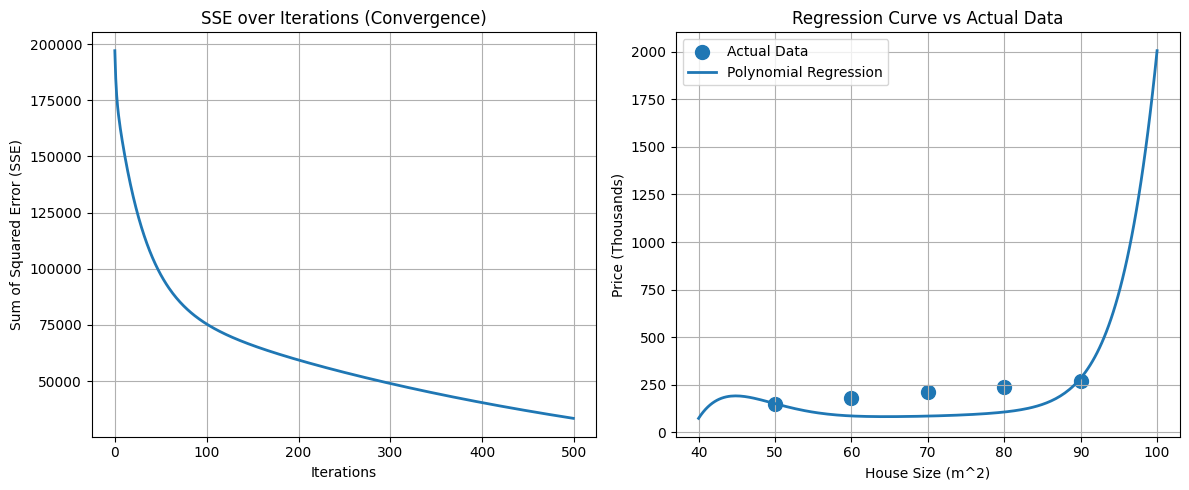

In [71]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(range(len(model.SSE_values)), 
         model.SSE_values, 
         linewidth=2)

plt.title('SSE over Iterations (Convergence)')
plt.xlabel('Iterations')
plt.ylabel('Sum of Squared Error (SSE)')
plt.grid(True)

plt.subplot(1, 2, 2)

# Scatter original data
plt.scatter(x, y, s=100, label='Actual Data')

# Generate smooth curve
x_line = np.linspace(min(x)-10, max(x)+10, 200)

x_line_scaled = scaler.transform(x_line.reshape(-1,1))

y_line = model.predict(x_line_scaled)

plt.plot(x_line, y_line, linewidth=2, label='Polynomial Regression')

plt.title('Regression Curve vs Actual Data')
plt.xlabel('House Size (m^2)')
plt.ylabel('Price (Thousands)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()